# k * RMSE Safety Stock Optimization

This notebook demonstrates the new `k_rmse` safety stock method with two policy-optimization flows:

- Optimize `k` to minimize total simulation cost.
- Optimize `k` subject to a fixed fill-rate target.


## Setup


In [1]:
from collections import defaultdict
from dataclasses import replace

import pandas as pd
import matplotlib.pyplot as plt

from replenishment import (
    InventoryState,
    PointForecastOptimizationPolicy,
    build_point_forecast_article_configs_from_standard_rows,
    build_replenishment_decisions_from_simulations,
    generate_standard_simulation_rows,
    optimize_k_rmse_factors,
    optimize_k_rmse_factors_for_fill_rate,
    plot_replenishment_decisions,
    replenishment_decision_rows_to_dataframe,
    simulate_replenishment_for_articles,
    split_standard_simulation_rows,
    standard_simulation_rows_to_dataframe,
)


### Parameters


In [2]:
review_period = 1
forecast_horizon = 1
rmse_window = 1

candidate_k = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]
target_fill_rate = 0.95

# Optional: increase safety stock when forecasted demand is above a baseline.
demand_buffer_strength = 0.5
demand_buffer_reference = 20.0
demand_buffer_max_multiplier = 1.8


## Generate Data


In [3]:
rows = generate_standard_simulation_rows(
    n_unique_ids=1,
    periods=24,
    start_date="2031-01-01",
    frequency_days=30,
    forecast_start_period=14,
    history_mean=50,
    history_std=8,
    forecast_mean=48,
    forecast_std=7,
    lead_time=2,
    initial_on_hand=30,
    current_stock=30,
    holding_cost_per_unit=0.1,
    stockout_cost_per_unit=2.0,
    order_cost_per_order=0.0,
    seed=13,
)

backtest_rows, forecast_rows = split_standard_simulation_rows(rows)

backtest_actuals = defaultdict(list)
for row in backtest_rows:
    backtest_actuals[row.unique_id].append(int(row.actuals))

rows_df = standard_simulation_rows_to_dataframe(rows, library="pandas")
rows_df.head()


,unique_id,ds,forecast,actuals,holding_cost_per_unit,stockout_cost_per_unit,order_cost_per_order,lead_time,initial_on_hand,current_stock,is_forecast,forecast_p50,forecast_p90
0,A,2031-01-01,47,62.0,0.1,2.0,0.0,2,30,30,False,47,59
1,A,2031-01-31,43,36.0,0.1,2.0,0.0,2,30,30,False,43,54
2,A,2031-03-02,50,55.0,0.1,2.0,0.0,2,30,30,False,50,62
3,A,2031-04-01,51,55.0,0.1,2.0,0.0,2,30,30,False,51,64
4,A,2031-05-01,48,46.0,0.1,2.0,0.0,2,30,30,False,48,60


## 1) Optimize `k` for Minimum Total Cost


In [4]:
backtest_configs = build_point_forecast_article_configs_from_standard_rows(
    backtest_rows,
    service_level_factor=1.0,
    review_period=review_period,
    forecast_horizon=forecast_horizon,
    rmse_window=rmse_window,
    safety_stock_method="k_rmse",
)

optimized_cost = optimize_k_rmse_factors(backtest_configs, candidate_k=candidate_k)

cost_summary = pd.DataFrame(
    [
        {
            "unique_id": uid,
            "k": result.service_level_factor,
            "backtest_fill_rate": result.simulation.summary.fill_rate,
            "backtest_total_cost": result.simulation.summary.total_cost,
        }
        for uid, result in optimized_cost.items()
    ]
).sort_values("unique_id")

cost_summary


,unique_id,k,backtest_fill_rate,backtest_total_cost
0,A,4.0,0.780939,311.9


In [5]:
k_by_article = {uid: result.service_level_factor for uid, result in optimized_cost.items()}

forecast_configs_cost = build_point_forecast_article_configs_from_standard_rows(
    forecast_rows,
    service_level_factor=k_by_article,
    review_period=review_period,
    forecast_horizon=forecast_horizon,
    rmse_window=rmse_window,
    safety_stock_method="k_rmse",
    use_current_stock=True,
    actuals_override=backtest_actuals,
)
forecast_sims_cost = simulate_replenishment_for_articles(forecast_configs_cost)

decision_rows_cost = build_replenishment_decisions_from_simulations(
    forecast_rows,
    forecast_sims_cost,
    sigma=k_by_article,
    service_level_mode="factor",
)
decision_df_cost = replenishment_decision_rows_to_dataframe(decision_rows_cost, library="pandas")
decision_df_cost.head()


,unique_id,ds,quantity,demand,forecast_quantity,forecast_quantity_lead_time,reorder_point,order_up_to,incoming_stock,starting_stock,...,current_stock,on_order,backorders,missed_sales,sigma,aggregation_window,review_period,forecast_horizon,rmse_window,percentile_target
0,A,2032-02-25,41,36,36,41,85.0,121.0,0,30,...,0,41,0,6,4.0,1,1,1,1,None
1,A,2032-03-26,108,49,49,45,90.0,139.0,0,0,...,0,149,0,49,4.0,1,1,1,1,None
2,A,2032-04-25,18,41,41,43,86.0,127.0,41,41,...,0,126,0,0,4.0,1,1,1,1,None
3,A,2032-05-25,48,45,45,54,88.0,133.0,108,108,...,63,66,0,0,4.0,1,1,1,1,None
4,A,2032-06-24,29,43,43,47,97.0,140.0,18,81,...,38,77,0,0,4.0,1,1,1,1,None


<Axes: title={'center': 'k*RMSE Safety Stock (k optimized for minimum cost)'}, xlabel='Date', ylabel='Units'>

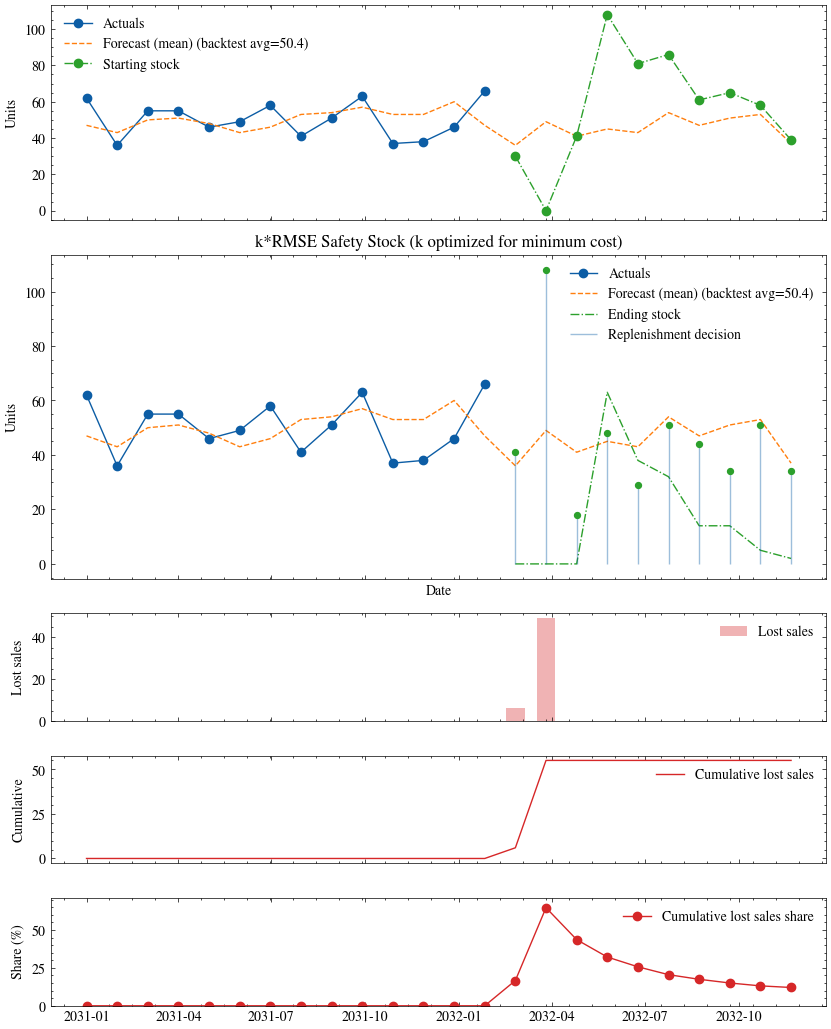

In [6]:
example_id = decision_df_cost["unique_id"].iloc[0]
plot_replenishment_decisions(
    rows_df,
    decision_df_cost,
    unique_id=example_id,
    title="k*RMSE Safety Stock (k optimized for minimum cost)",
    decision_style="line",
)


## 2) Optimize `k` with Fill-Rate Target


In [7]:
optimized_fill = optimize_k_rmse_factors_for_fill_rate(
    backtest_configs,
    candidate_k=candidate_k,
    target_fill_rate=target_fill_rate,
)

fill_summary = pd.DataFrame(
    [
        {
            "unique_id": uid,
            "k": result.k,
            "meets_fill_rate_target": result.meets_fill_rate_target,
            "achieved_fill_rate": result.achieved_fill_rate,
            "backtest_total_cost": result.simulation.summary.total_cost,
        }
        for uid, result in optimized_fill.items()
    ]
).sort_values("unique_id")

fill_summary


,unique_id,k,meets_fill_rate_target,achieved_fill_rate,backtest_total_cost
0,A,4.0,False,0.780939,311.9


In [8]:
fill_k_by_article = {uid: result.k for uid, result in optimized_fill.items()}

forecast_configs_fill = build_point_forecast_article_configs_from_standard_rows(
    forecast_rows,
    service_level_factor=fill_k_by_article,
    review_period=review_period,
    forecast_horizon=forecast_horizon,
    rmse_window=rmse_window,
    safety_stock_method="k_rmse",
    use_current_stock=True,
    actuals_override=backtest_actuals,
)
forecast_sims_fill = simulate_replenishment_for_articles(forecast_configs_fill)

decision_rows_fill = build_replenishment_decisions_from_simulations(
    forecast_rows,
    forecast_sims_fill,
    sigma=fill_k_by_article,
    service_level_mode="factor",
)
decision_df_fill = replenishment_decision_rows_to_dataframe(decision_rows_fill, library="pandas")
decision_df_fill.head()


,unique_id,ds,quantity,demand,forecast_quantity,forecast_quantity_lead_time,reorder_point,order_up_to,incoming_stock,starting_stock,...,current_stock,on_order,backorders,missed_sales,sigma,aggregation_window,review_period,forecast_horizon,rmse_window,percentile_target
0,A,2032-02-25,41,36,36,41,85.0,121.0,0,30,...,0,41,0,6,4.0,1,1,1,1,None
1,A,2032-03-26,108,49,49,45,90.0,139.0,0,0,...,0,149,0,49,4.0,1,1,1,1,None
2,A,2032-04-25,18,41,41,43,86.0,127.0,41,41,...,0,126,0,0,4.0,1,1,1,1,None
3,A,2032-05-25,48,45,45,54,88.0,133.0,108,108,...,63,66,0,0,4.0,1,1,1,1,None
4,A,2032-06-24,29,43,43,47,97.0,140.0,18,81,...,38,77,0,0,4.0,1,1,1,1,None


<Axes: title={'center': 'k*RMSE Safety Stock (target fill rate = 95%)'}, xlabel='Date', ylabel='Units'>

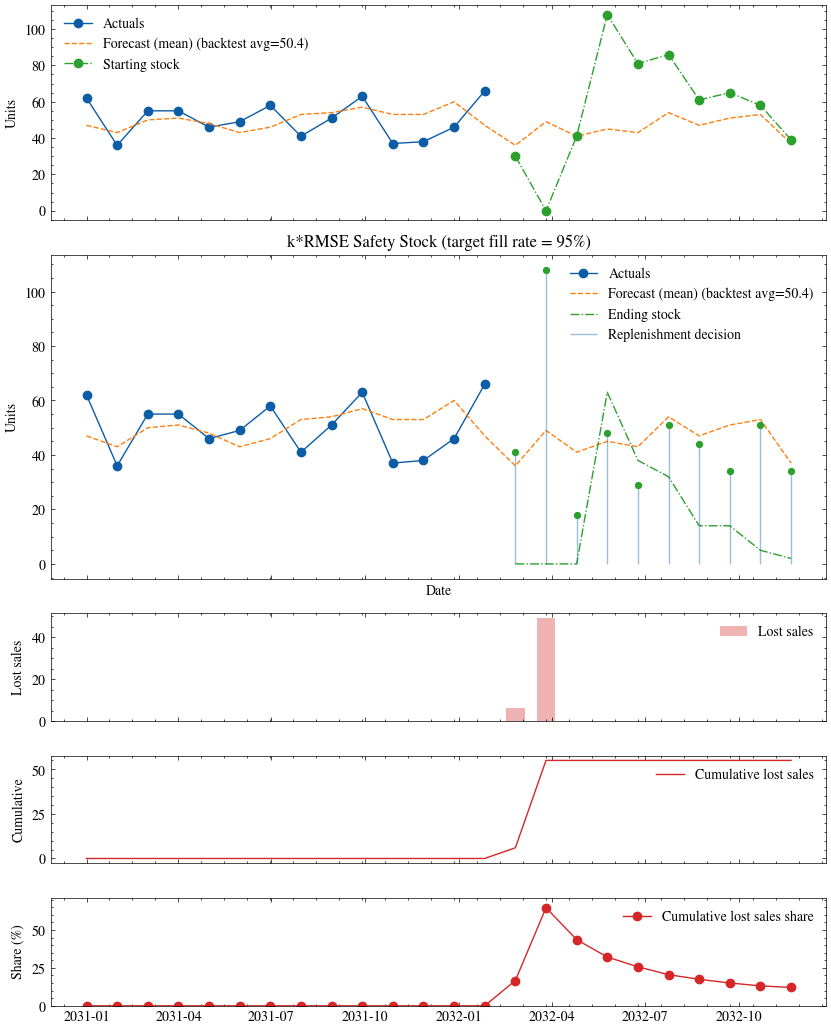

In [9]:
plot_replenishment_decisions(
    rows_df,
    decision_df_fill,
    unique_id=example_id,
    title=f"k*RMSE Safety Stock (target fill rate = {target_fill_rate:.0%})",
    decision_style="line",
)


## 3) Optional: Increase Safety Stock with Forecast Level

You can keep `k * RMSE` and also scale safety stock upward when forecasts rise by setting:

- `demand_buffer_strength`
- `demand_buffer_reference`
- `demand_buffer_max_multiplier`


In [10]:
forecast_configs_fill_buffered = {
    uid: replace(
        config,
        policy=replace(
            config.policy,
            demand_buffer_strength=demand_buffer_strength,
            demand_buffer_reference=demand_buffer_reference,
            demand_buffer_max_multiplier=demand_buffer_max_multiplier,
        ),
    )
    for uid, config in forecast_configs_fill.items()
}

forecast_sims_fill_buffered = simulate_replenishment_for_articles(
    forecast_configs_fill_buffered
)

buffered_summary = pd.DataFrame(
    [
        {
            "unique_id": uid,
            "k": fill_k_by_article[uid],
            "fill_rate_base": forecast_sims_fill[uid].summary.fill_rate,
            "fill_rate_buffered": sim.summary.fill_rate,
            "total_cost_base": forecast_sims_fill[uid].summary.total_cost,
            "total_cost_buffered": sim.summary.total_cost,
        }
        for uid, sim in forecast_sims_fill_buffered.items()
    ]
).sort_values("unique_id")

buffered_summary


,unique_id,k,fill_rate_base,fill_rate_buffered,total_cost_base,total_cost_buffered
0,A,4.0,0.879386,0.879386,126.8,160.1


In [11]:
def forecast_sum_with_carry_forward(values: list[int], start: int, horizon: int) -> int:
    return sum(values[idx] if idx < len(values) else values[-1] for idx in range(start, start + horizon))


state = InventoryState(period=1, on_hand=0, on_order=0, backorders=0)
scenario_forecasts = {
    "baseline_level": [10, 10, 10, 10, 10],
    "higher_forecast_level": [10, 10, 10, 20, 20],
}

buffer_demo_rows = []
for scenario, forecast_values in scenario_forecasts.items():
    for buffered in (False, True):
        policy = PointForecastOptimizationPolicy(
            forecast=forecast_values,
            actuals=[10, 10, 10, 10, 10],
            lead_time=1,
            forecast_horizon=2,
            service_level_factor=1.0,
            safety_stock_method="k_rmse",
            fixed_rmse=4.0,
            demand_buffer_strength=demand_buffer_strength if buffered else 0.0,
            demand_buffer_reference=demand_buffer_reference if buffered else None,
            demand_buffer_max_multiplier=demand_buffer_max_multiplier if buffered else None,
        )
        start_period = state.period + max(1, policy.lead_time)
        forecast_qty = forecast_sum_with_carry_forward(
            forecast_values,
            start_period,
            policy.forecast_horizon if policy.forecast_horizon is not None else 1,
        )
        order_qty = policy.order_quantity_for(state)
        buffer_demo_rows.append(
            {
                "scenario": scenario,
                "buffered": buffered,
                "forecast_quantity": forecast_qty,
                "order_quantity": order_qty,
                "implied_safety_stock": order_qty - forecast_qty,
            }
        )

buffer_demo_df = pd.DataFrame(buffer_demo_rows)
buffer_demo_df


,scenario,buffered,forecast_quantity,order_quantity,implied_safety_stock
0,baseline_level,False,20,24,4
1,baseline_level,True,20,24,4
2,higher_forecast_level,False,30,34,4
3,higher_forecast_level,True,30,35,5


### Plot: Safety Stock Growth Across 3 Increasing Forecast Trends

This plot compares 3 `unique_id` scenarios with medium, strong, and very strong upward forecast trends.
The buffered policy keeps `k * RMSE` and adds a forecast-level multiplier, so safety stock rises as forecast levels rise.


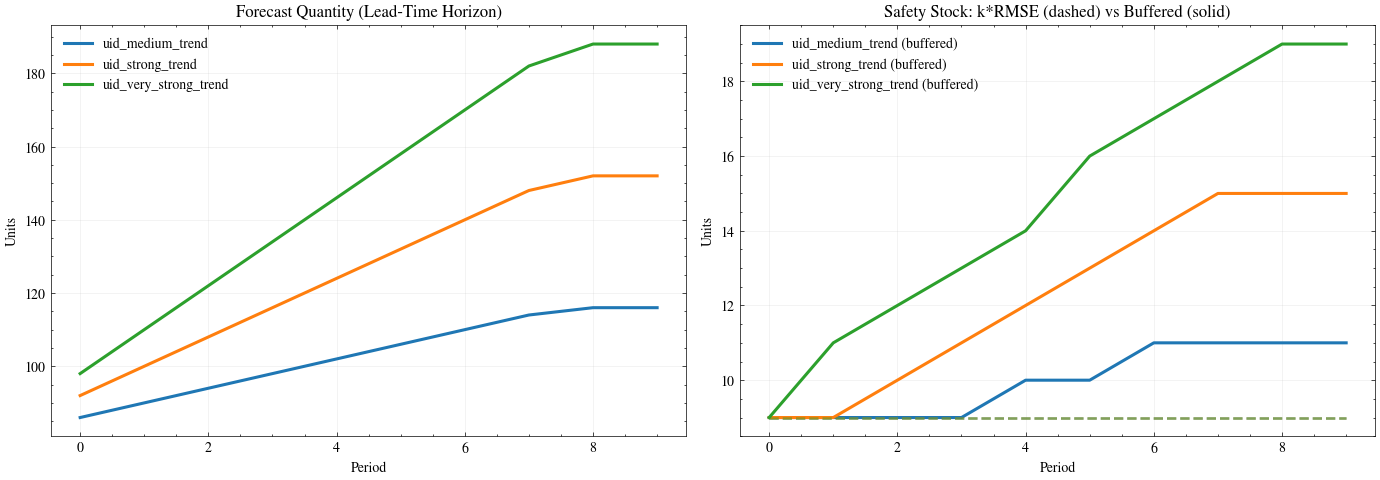

safety_stock_k_rmse     safety_stock_buffered    
                                      min max                   min max
unique_id                                                              
uid_medium_trend                        9   9                     9  11
uid_strong_trend                        9   9                     9  15
uid_very_strong_trend                   9   9                     9  19

In [12]:
trend_forecasts_by_uid = {
    "uid_medium_trend": [40, 42, 44, 46, 48, 50, 52, 54, 56, 58],
    "uid_strong_trend": [40, 44, 48, 52, 56, 60, 64, 68, 72, 76],
    "uid_very_strong_trend": [40, 46, 52, 58, 64, 70, 76, 82, 88, 94],
}

trend_demo_k = 1.5
trend_demo_fixed_rmse = 6.0
trend_demo_lead_time = 1
trend_demo_forecast_horizon = 2

# Plot-specific buffer settings for clear separation of trend effects.
trend_buffer_strength = 1.2
trend_buffer_reference = 100.0
trend_buffer_max_multiplier = 2.5

trend_rows = []
for uid, forecast_values in trend_forecasts_by_uid.items():
    base_policy = PointForecastOptimizationPolicy(
        forecast=forecast_values,
        actuals=[forecast_values[0]] * len(forecast_values),
        lead_time=trend_demo_lead_time,
        forecast_horizon=trend_demo_forecast_horizon,
        service_level_factor=trend_demo_k,
        safety_stock_method="k_rmse",
        fixed_rmse=trend_demo_fixed_rmse,
        demand_buffer_strength=0.0,
        demand_buffer_reference=None,
        demand_buffer_max_multiplier=None,
    )
    buffered_policy = PointForecastOptimizationPolicy(
        forecast=forecast_values,
        actuals=[forecast_values[0]] * len(forecast_values),
        lead_time=trend_demo_lead_time,
        forecast_horizon=trend_demo_forecast_horizon,
        service_level_factor=trend_demo_k,
        safety_stock_method="k_rmse",
        fixed_rmse=trend_demo_fixed_rmse,
        demand_buffer_strength=trend_buffer_strength,
        demand_buffer_reference=trend_buffer_reference,
        demand_buffer_max_multiplier=trend_buffer_max_multiplier,
    )

    for period in range(len(forecast_values)):
        state = InventoryState(period=period, on_hand=0, on_order=0, backorders=0)
        start_period = period + max(1, trend_demo_lead_time)
        forecast_qty = forecast_sum_with_carry_forward(
            forecast_values,
            start_period,
            trend_demo_forecast_horizon,
        )
        base_order = base_policy.order_quantity_for(state)
        buffered_order = buffered_policy.order_quantity_for(state)

        trend_rows.append(
            {
                "unique_id": uid,
                "period": period,
                "forecast_quantity": forecast_qty,
                "safety_stock_k_rmse": base_order - forecast_qty,
                "safety_stock_buffered": buffered_order - forecast_qty,
            }
        )

trend_df = pd.DataFrame(trend_rows)

uids = list(trend_forecasts_by_uid.keys())
colors = {uid: plt.get_cmap("tab10")(i) for i, uid in enumerate(uids)}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

for uid in uids:
    group = trend_df[trend_df["unique_id"] == uid]
    color = colors[uid]
    axes[0].plot(
        group["period"],
        group["forecast_quantity"],
        label=uid,
        color=color,
        linewidth=2.2,
    )
    axes[1].plot(
        group["period"],
        group["safety_stock_buffered"],
        label=uid + " (buffered)",
        color=color,
        linewidth=2.2,
    )
    axes[1].plot(
        group["period"],
        group["safety_stock_k_rmse"],
        color=color,
        linestyle="--",
        alpha=0.45,
        linewidth=1.8,
    )

axes[0].set_title("Forecast Quantity (Lead-Time Horizon)")
axes[0].set_xlabel("Period")
axes[0].set_ylabel("Units")
axes[0].grid(alpha=0.2)
axes[0].legend(loc="upper left")

axes[1].set_title("Safety Stock: k*RMSE (dashed) vs Buffered (solid)")
axes[1].set_xlabel("Period")
axes[1].set_ylabel("Units")
axes[1].grid(alpha=0.2)
axes[1].legend(loc="upper left")

plt.tight_layout()
plt.show()

trend_summary = trend_df.groupby("unique_id")[
    ["safety_stock_k_rmse", "safety_stock_buffered"]
].agg(["min", "max"])
trend_summary


## Notes

- Old behavior is still available via `safety_stock_method="sqrt_horizon"`.
- This notebook intentionally uses `safety_stock_method="k_rmse"` to apply raw `k * RMSE`.
- Set `demand_buffer_strength > 0` to increase safety stock when forecast quantities are above a reference level.
